# Практична робота №10
## Дослідження неперервних розподілів за допомогою бібліотеки scipy.stats
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів, середня липнева норма 20°C)  
**№ у журналі:** 26


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(6)
t_ref = 20
daily_temps = np.random.normal(loc=t_ref, scale=2.5, size=30)

print("Згенеровані показники денної температури:")
print(np.round(daily_temps, 2))
print(f"Середнє арифметичне: {daily_temps.mean():.2f}")
print(f"Стандартне відхилення (ddof=1): {daily_temps.std(ddof=1):.2f}")


Згенеровані показники денної температури:
[19.22 21.82 20.54 17.75 13.78 22.28 22.82 16.21 24.1  18.93 26.58 21.5
 19.16 23.09 20.28 20.32 20.19 19.61 21.59 22.03 20.89 24.53 16.61 18.84
 22.06 17.06 23.91 21.78 19.55 21.34]
Середнє арифметичне: 20.61
Стандартне відхилення (ddof=1): 2.71


In [2]:
mu_hat = daily_temps.mean()
sigma_hat = daily_temps.std(ddof=1)

norm_model = stats.norm(loc=mu_hat, scale=sigma_hat)
print(f"Параметри апроксимуючого нормального розподілу: mu={mu_hat:.2f}, sigma={sigma_hat:.2f}")


Параметри апроксимуючого нормального розподілу: mu=20.61, sigma=2.71


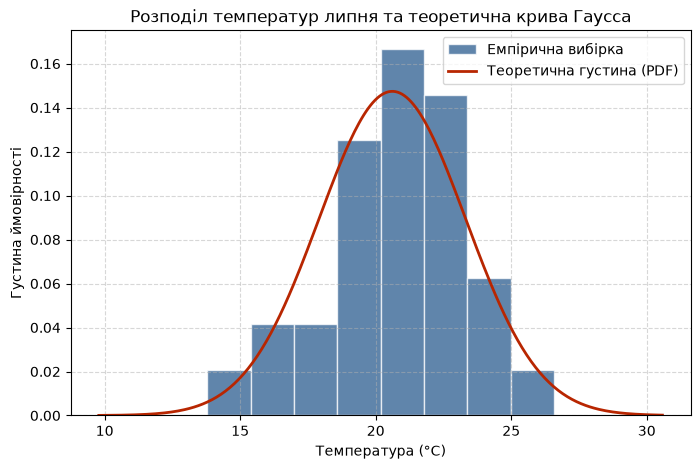

In [3]:
x_axis = np.linspace(daily_temps.min() - 4, daily_temps.max() + 4, 250)

plt.figure(figsize=(8, 5))
plt.hist(daily_temps, bins=8, density=True, edgecolor="white", color="#2b5c8f", alpha=0.75, label="Емпірична вибірка")
plt.plot(x_axis, norm_model.pdf(x_axis), color="#b82601", lw=2, label="Теоретична густина (PDF)")
plt.xlabel("Температура (°C)")
plt.ylabel("Густина ймовірності")
plt.title("Розподіл температур липня та теоретична крива Гаусса")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


In [4]:
p_sigma = norm_model.cdf(mu_hat + sigma_hat) - norm_model.cdf(mu_hat - sigma_hat)
print(f"Ймовірність потрапляння у діапазон [mu - sigma, mu + sigma]: {p_sigma:.4f}")
print("Розрахована частка узгоджується з правилом 'одного сигма' (~68.27%) для нормального розподілу.")


Ймовірність потрапляння у діапазон [mu - sigma, mu + sigma]: 0.6827
Розрахована частка узгоджується з правилом 'одного сигма' (~68.27%) для нормального розподілу.


In [5]:
q95 = norm_model.ppf(0.95)
print(f"95-й процентиль денної температури: {q95:.2f} °C")
print("Функція .ppf(q) обчислює квантиль, тобто значення x, для якого P(X <= x) = q.")


95-й процентиль денної температури: 25.06 °C
Функція .ppf(q) обчислює квантиль, тобто значення x, для якого P(X <= x) = q.


### Відповіді на контрольні запитання

1. **У чому полягає відмінність між функціями .pdf(x) та .cdf(x)?**  
   - `.pdf(x)` (Probability Density Function) визначає диференціальну густину розподілу в точці $x$, тобто локальну концентрацію ймовірності навколо цього значення.
   - `.cdf(x)` (Cumulative Distribution Function) виражає інтегральну ймовірність того, що випадкова величина набуде значення менше або рівне заданому: $F(x) = P(X \le x)$.

2. **Чи може значення .pdf(x) перевищувати одиницю?**  
   - Так, оскільки це не ймовірність події, а густина. Якщо випадкова величина сконцентрована у вузькому діапазоні (мале стандартне відхилення $\sigma$), значення густини в околі моди може бути суттєво більшим за 1. Одиниці дорівнює лише інтеграл від усієї функції густини по всій області визначення.

3. **Який зміст має квантильна функція .ppf()?**  
   - Метод `.ppf()` є оберненою функцією до інтегральної функції розподілу ($CDF^{-1}$). Вона приймає на вхід рівень ймовірності $q \in [0; 1]$ та знаходить відповідний поріг $x$, лівіше якого зосереджено рівно $q \cdot 100\%$ спостережень.
